In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import zipfile

zip_path = '/content/dataset.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [2]:
import os
import cv2
import numpy as np

DATASET_PATH = "/content/dataset"

def adjust_brightness(image, value):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # tambah brightness
    v = np.clip(v.astype(np.int16) + value, 0, 255).astype(np.uint8)

    final_hsv = cv2.merge((h, s, v))
    img = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)
    return img


def augment_dataset(base_path):
    for split in ["train", "test"]:
        split_path = os.path.join(base_path, split)

        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)

            if not os.path.isdir(class_path):
                continue

            print(f"\n📂 Processing: {split}/{class_name}")

            for file in os.listdir(class_path):
                img_path = os.path.join(class_path, file)

                # skip file hasil augmentasi biar gak dobel terus
                if "_bright" in file or "_dark" in file:
                    continue

                img = cv2.imread(img_path)
                if img is None:
                    continue

                filename, ext = os.path.splitext(file)

                # +20 brightness
                bright_img = adjust_brightness(img, 20)
                bright_path = os.path.join(class_path, f"{filename}_bright{ext}")
                cv2.imwrite(bright_path, bright_img)

                # -20 brightness
                dark_img = adjust_brightness(img, -20)
                dark_path = os.path.join(class_path, f"{filename}_dark{ext}")
                cv2.imwrite(dark_path, dark_img)

            print("✔️ Selesai augmentasi")


# RUN
augment_dataset(DATASET_PATH)


📂 Processing: train/Dymas
✔️ Selesai augmentasi

📂 Processing: train/Febri
✔️ Selesai augmentasi

📂 Processing: train/Yusril
✔️ Selesai augmentasi

📂 Processing: train/Sephia
✔️ Selesai augmentasi

📂 Processing: train/Dela
✔️ Selesai augmentasi

📂 Processing: test/Dymas
✔️ Selesai augmentasi

📂 Processing: test/Febri
✔️ Selesai augmentasi

📂 Processing: test/Yusril
✔️ Selesai augmentasi

📂 Processing: test/Sephia
✔️ Selesai augmentasi

📂 Processing: test/Dela
✔️ Selesai augmentasi


In [3]:

# 1. IMPORT

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Model


In [4]:

# 2. LOAD DATASET (TRAIN & TEST TERPISAH)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +
                                     'haarcascade_frontalface_default.xml')


def load_images_with_face(base_path):
    images = []
    labels = []
    class_names = sorted(os.listdir(base_path))

    detection_summary = {}

    for label_idx, class_name in enumerate(class_names):
        class_path = os.path.join(base_path, class_name)

        total = 0
        detected = 0

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            img = cv2.imread(img_path)
            if img is None:
                continue

            total += 1

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            faces = face_cascade.detectMultiScale(gray, 1.3, 5)

            if len(faces) == 0:
                continue

            detected += 1

            (x, y, w, h) = faces[0]
            face = gray[y:y+h, x:x+w]

            face_resized = cv2.resize(face, (224, 224))

            images.append(face_resized)
            labels.append(label_idx)

        detection_summary[class_name] = (detected, total)

    return np.array(images), np.array(labels), class_names, detection_summary


TRAIN_PATH = "/content/dataset/train"
TEST_PATH = "/content/dataset/test"

# LOAD TRAIN
train_images, train_labels, class_names, train_summary = load_images_with_face(TRAIN_PATH)

print("\n📊 DETEKSI WAJAH (TRAIN)")
for k, v in train_summary.items():
    print(f"{k}: {v[0]} / {v[1]} wajah terdeteksi")

# LOAD TEST
test_images, test_labels, _, test_summary = load_images_with_face(TEST_PATH)

print("\n📊 DETEKSI WAJAH (TEST)")
for k, v in test_summary.items():
    print(f"{k}: {v[0]} / {v[1]} wajah terdeteksi")


📊 DETEKSI WAJAH (TRAIN)
Dela: 53 / 90 wajah terdeteksi
Dymas: 84 / 90 wajah terdeteksi
Febri: 73 / 90 wajah terdeteksi
Sephia: 82 / 90 wajah terdeteksi
Yusril: 77 / 90 wajah terdeteksi

📊 DETEKSI WAJAH (TEST)
Dela: 20 / 36 wajah terdeteksi
Dymas: 36 / 36 wajah terdeteksi
Febri: 27 / 36 wajah terdeteksi
Sephia: 36 / 36 wajah terdeteksi
Yusril: 36 / 36 wajah terdeteksi


In [5]:
# 3. OTSU & ADAPTIVE

def apply_otsu(images):
    return np.array([
        cv2.threshold(img, 0, 255,
                      cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
        for img in images
    ])


def apply_adaptive(images):
    return np.array([
        cv2.adaptiveThreshold(img, 255,
                              cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                              cv2.THRESH_BINARY, 11, 2)
        for img in images
    ])


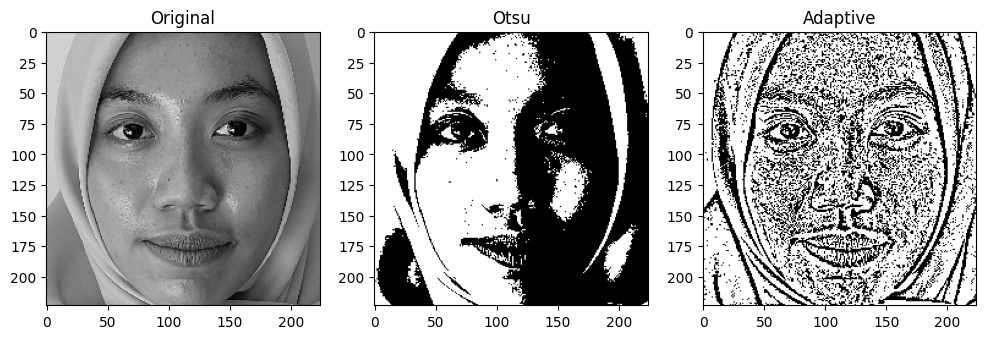

In [7]:
# 4. VISUAL SAMPLE

idx = 5

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(train_images[idx], cmap='gray'); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(apply_otsu(train_images)[idx], cmap='gray'); plt.title("Otsu")
plt.subplot(1,3,3); plt.imshow(apply_adaptive(train_images)[idx], cmap='gray'); plt.title("Adaptive")
plt.show()


In [8]:
# 5. PREPARE VGG16 INPUT

def prepare_for_vgg(imgs):
    imgs = np.stack((imgs,)*3, axis=-1)
    return imgs.astype("float32") / 255.0


Xo_train = prepare_for_vgg(apply_otsu(train_images))
Xa_train = prepare_for_vgg(apply_adaptive(train_images))

Xo_test = prepare_for_vgg(apply_otsu(test_images))
Xa_test = prepare_for_vgg(apply_adaptive(test_images))

yo_train = train_labels
ya_train = train_labels

yo_test = test_labels
ya_test = test_labels


In [9]:
# 6. BUILD MODEL

def build_vgg(num_classes):
    base = VGG16(include_top=False,
                 weights='imagenet',
                 input_tensor=Input(shape=(224,224,3)))

    base.trainable = False

    x = Flatten()(base.output)
    x = Dense(256, activation='relu')(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [10]:
# 7. TRAIN MODEL

model_otsu = build_vgg(len(class_names))
model_adap = build_vgg(len(class_names))

history_otsu = model_otsu.fit(Xo_train, yo_train,
                              epochs=10, validation_split=0.2)

history_adap = model_adap.fit(Xa_train, ya_train,
                              epochs=10, validation_split=0.2)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6915 - loss: 1.4462 - val_accuracy: 0.0000e+00 - val_loss: 39.3064
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 273ms/step - accuracy: 0.9458 - loss: 0.5878 - val_accuracy: 0.0000e+00 - val_loss: 28.2867
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.9729 - loss: 0.2291 - val_accuracy: 0.5405 - val_loss: 3.5146
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 260ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.8108 - val_loss: 0.6695
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 256ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8243 - val_loss: 0.4356
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 1.0000 - loss: 3.0822e-04 - val_accuracy: 0.8108 - val_loss: 0.4451
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - accuracy: 1.0000 - loss: 2.0070e-04 - val_accuracy: 0.7973 - val_loss: 0.4846
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━


📌 Akurasi Model (Otsu): 90.32%
📌 Akurasi Model (Adaptive): 98.71%


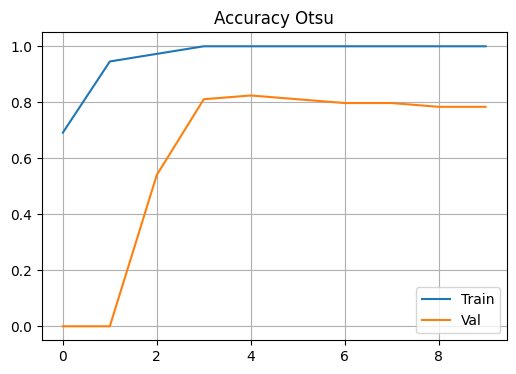

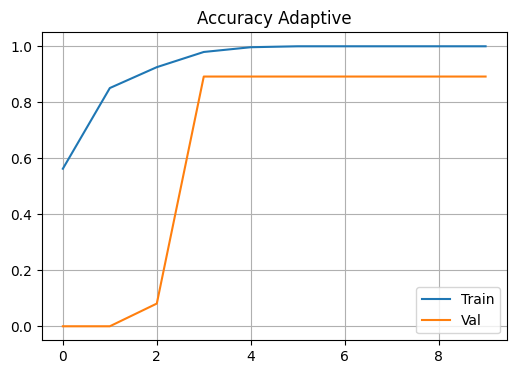

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 357ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 361ms/step


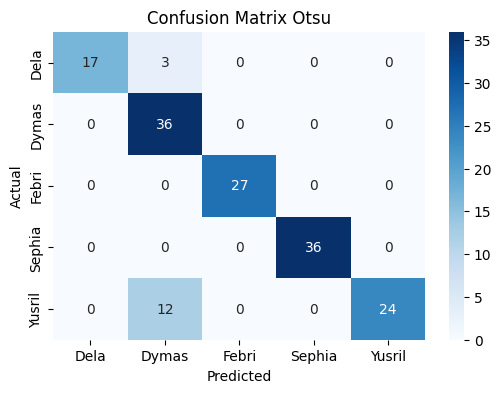

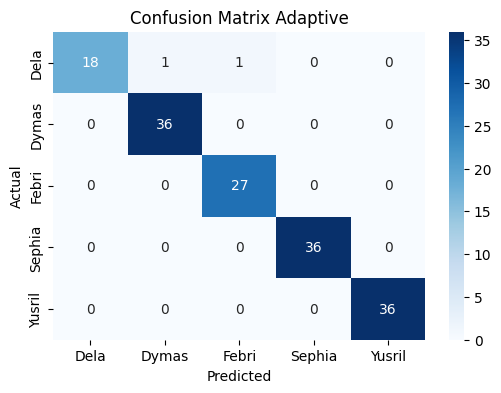


=== OTSU ===
              precision    recall  f1-score   support

        Dela       1.00      0.85      0.92        20
       Dymas       0.71      1.00      0.83        36
       Febri       1.00      1.00      1.00        27
      Sephia       1.00      1.00      1.00        36
      Yusril       1.00      0.67      0.80        36

    accuracy                           0.90       155
   macro avg       0.94      0.90      0.91       155
weighted avg       0.93      0.90      0.90       155


=== ADAPTIVE ===
              precision    recall  f1-score   support

        Dela       1.00      0.90      0.95        20
       Dymas       0.97      1.00      0.99        36
       Febri       0.96      1.00      0.98        27
      Sephia       1.00      1.00      1.00        36
      Yusril       1.00      1.00      1.00        36

    accuracy                           0.99       155
   macro avg       0.99      0.98      0.98       155
weighted avg       0.99      0.99      0.99  

In [11]:
# 8. EVALUASI

loss_o, acc_o = model_otsu.evaluate(Xo_test, yo_test, verbose=0)
print(f"\n📌 Akurasi Model (Otsu): {acc_o * 100:.2f}%")

loss_a, acc_a = model_adap.evaluate(Xa_test, ya_test, verbose=0)
print(f"📌 Akurasi Model (Adaptive): {acc_a * 100:.2f}%")


def plot_accuracy(history, title):
    plt.figure(figsize=(6,4))
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_accuracy(history_otsu, "Accuracy Otsu")
plot_accuracy(history_adap, "Accuracy Adaptive")


# %% CONFUSION MATRIX

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


pred_otsu = np.argmax(model_otsu.predict(Xo_test), axis=1)
pred_adap = np.argmax(model_adap.predict(Xa_test), axis=1)

plot_confusion(yo_test, pred_otsu, "Confusion Matrix Otsu")
plot_confusion(ya_test, pred_adap, "Confusion Matrix Adaptive")


# %% CLASSIFICATION REPORT

print("\n=== OTSU ===")
print(classification_report(yo_test, pred_otsu, target_names=class_names))

print("\n=== ADAPTIVE ===")
print(classification_report(ya_test, pred_adap, target_names=class_names))


In [12]:
# 9. PREDIKSI GAMBAR BARU

def classify_and_show(img_path, model, mode="otsu"):

    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("Gambar tidak ditemukan")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    if len(faces) == 0:
        raise ValueError("Tidak ditemukan wajah")

    x, y, w, h = faces[0]
    face = gray[y:y+h, x:x+w]

    face_resized = cv2.resize(face, (224, 224))

    # Threshold
    if mode == "otsu":
        processed = cv2.threshold(face_resized, 0, 255,
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    elif mode == "adaptive":
        processed = cv2.adaptiveThreshold(face_resized, 255,
                                          cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                          cv2.THRESH_BINARY, 11, 2)
    else:
        raise ValueError("Mode salah")

    # VGG input
    face_3ch = np.stack((processed,)*3, axis=-1)
    face_3ch = face_3ch.astype("float32") / 255.0
    face_3ch = np.expand_dims(face_3ch, axis=0)

    pred = model.predict(face_3ch)
    idx = np.argmax(pred)
    conf = np.max(pred)

    label = class_names[idx]

    # ===== VISUAL =====
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(face_resized, cmap="gray")
    plt.title("Detected Face")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(processed, cmap="gray")
    plt.title(f"{mode.upper()} → {label} ({conf:.2f})")
    plt.axis("off")

    plt.show()

    return label, conf

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


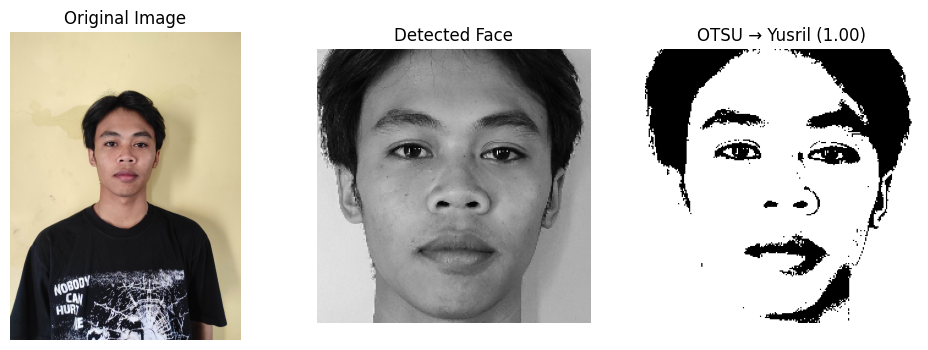

Prediksi: Yusril
Confidence: 0.9999963


In [13]:
label, conf = classify_and_show(
    "/content/dataset/train/Yusril/yusril 0.jpg",
    model_otsu,
    mode="otsu"
)

print("Prediksi:", label)
print("Confidence:", conf)

In [14]:
# %% SAVE MODEL

model_otsu.save("model_otsu.h5")
model_adap.save("model_adap.h5")